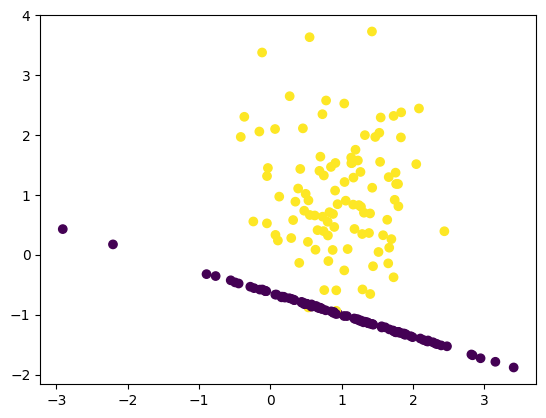

In [59]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,n_clusters_per_class=1,class_sep=1,random_state=2)

plt.scatter(X[:,0], X[:,1], c=y)
# plt.label()
plt.show()




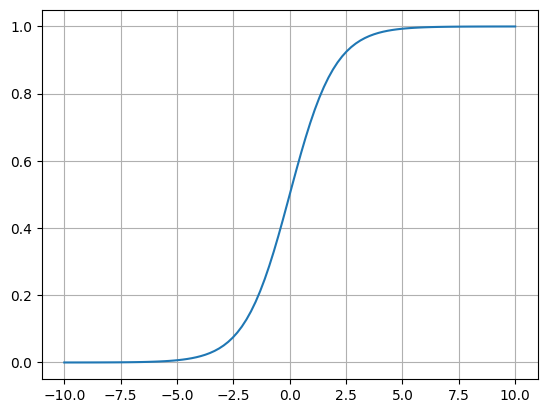

In [60]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.grid(True)
plt.show()


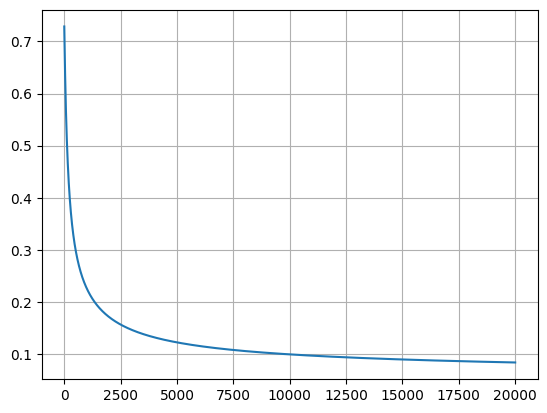

In [61]:
# print(X)
Xb = np.hstack((np.ones((X.shape[0], 1)), X))
# print(Xb)
y = y.reshape(-1, 1)
# print(y)

def predict_class(Xb, w):
  return sigmoid(Xb @ w)

def gradient(Xb, w, y):
  p = predict_class(Xb, w)
  return Xb.T @ (p - y) / Xb.shape[0]

def loss(Xb, w, y, eps=1e-9):
  p = predict_class(Xb, w)
  return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

w = np.random.randn(Xb.shape[1],1) * 0.1

max_steps = 20000
lr = 0.01
losses = []

for i in range(max_steps):
  g = gradient(Xb, w, y)
  w -= lr * g
  ls = loss(Xb, w, y)
  losses.append(ls)

plt.plot(losses)
plt.grid(True)


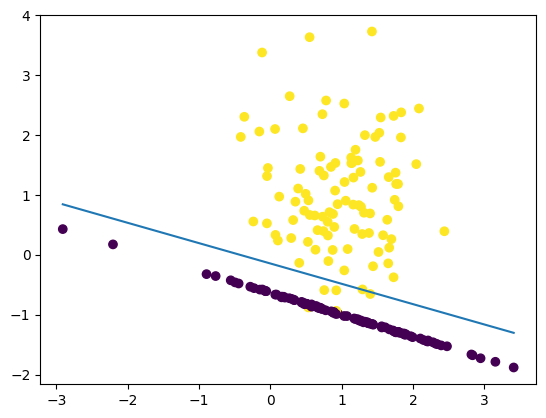

In [62]:
plt.scatter(X[:,0], X[:,1], c=y)
x_vals = np.array([min(X[:,0]), max(X[:,0])])
# w0 + w1*x + w2*y = 0
# y = -(w0 + w1*x)/w2
y_vals = (-w[0] - w[1] * x_vals) / w[2]
plt.plot(x_vals, y_vals)

plt.show()


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=20000)
clf.fit(X, y)

our_model_pred = (predict_class(Xb, w) > 0.5).astype(int)
sklearn_model_pred = clf.predict(X)

print("our model accuracy:",accuracy_score(y, our_model_pred))
print("sklearn model accuracy",accuracy_score(y, sklearn_model_pred))




our model accuracy: 0.975
sklearn model accuracy 0.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
1. Number of samples (200) x.shape (rows) --
2. Number of features (2) (coloumns)
3. Number of classes (binary or multi 1000 10,000 higher)
